In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from transformers import BertTokenizer, TFBertModel
import tensorflow_hub as hub
import tensorflow as tf



In [2]:
# Load dataset
df = pd.read_csv("/content/train_E6oV3lV-3.csv")
df


,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation
...,...,...,...
31957,31958,0,ate @user isz that youuu?ðððððð...
31958,31959,0,to see nina turner on the airwaves trying to...
31959,31960,0,listening to sad songs on a monday morning otw...
31960,31961,1,"@user #sikh #temple vandalised in in #calgary,..."


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31962 entries, 0 to 31961
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      31962 non-null  int64 
 1   label   31962 non-null  int64 
 2   tweet   31962 non-null  object
dtypes: int64(2), object(1)
memory usage: 749.2+ KB


In [4]:
df.describe()

,id,label
count,31962.000000,31962.000000
mean,15981.500000,0.070146
std,9226.778988,0.255397
min,1.000000,0.000000
25%,7991.250000,0.000000
50%,15981.500000,0.000000
75%,23971.750000,0.000000
max,31962.000000,1.000000


In [5]:
nltk.download('stopwords')
nltk.download('wordnet')
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\@\w+|\#','', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

df['cleaned_tweet'] = df['tweet'].apply(clean_text)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [33]:
df

,id,label,tweet,cleaned_tweet
0,1,0,@user when a father is dysfunctional and is s...,father dysfunctional selfish drag kid dysfunct...
1,2,0,@user @user thanks for #lyft credit i can't us...,thanks lyft credit cant use cause dont offer w...
2,3,0,bihday your majesty,bihday majesty
3,4,0,#model i love u take with u all the time in ...,model love u take u time urð ðððð ððð
4,5,0,factsguide: society now #motivation,factsguide society motivation
...,...,...,...,...
31957,31958,0,ate @user isz that youuu?ðððððð...,ate isz youuuðððððððððâï
31958,31959,0,to see nina turner on the airwaves trying to...,see nina turner airwave trying wrap mantle gen...
31959,31960,0,listening to sad songs on a monday morning otw...,listening sad song monday morning otw work sad
31960,31961,1,"@user #sikh #temple vandalised in in #calgary,...",sikh temple vandalised calgary wso condemns act


In [6]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(df['cleaned_tweet'], df['label'], test_size=0.2, random_state=42)

# Bag-of-Words
vectorizer_bow = CountVectorizer()
X_train_bow = vectorizer_bow.fit_transform(X_train)
X_test_bow = vectorizer_bow.transform(X_test)


In [7]:
# TF-IDF
vectorizer_tfidf = TfidfVectorizer()
X_train_tfidf = vectorizer_tfidf.fit_transform(X_train)
X_test_tfidf = vectorizer_tfidf.transform(X_test)

In [8]:
import numpy as np
from transformers import DistilBertTokenizer, TFDistilBertModel

# Using DistilBERT instead of BERT
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
bert_model = TFDistilBertModel.from_pretrained('distilbert-base-uncased')

def encode_with_bert(texts, max_length=64, batch_size=32):
    encoded_outputs = []

    for i in range(0, len(texts), batch_size):
        # Processing in batches to reduce memory usage
        batch_texts = texts[i:i + batch_size]
        inputs = tokenizer(batch_texts.tolist(), return_tensors='tf', padding=True, truncation=True, max_length=max_length)

        # Extracting the last hidden state for all tokens
        outputs = bert_model(inputs)[0][:, 0, :]  # [batch_size, max_seq_len, hidden_size] -> [batch_size, hidden_size]

        encoded_outputs.append(outputs)

    # Concatenate all batch outputs into a single numpy array
    return np.concatenate(encoded_outputs, axis=0)

# Apply encoding to training and test data
X_train_bert = encode_with_bert(X_train, max_length=64, batch_size=32)
X_test_bert = encode_with_bert(X_test, max_length=64, batch_size=32)


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_projector.bias', 'vocab_layer_norm.bias', 'vocab_transform.weight', 'vocab_layer_norm.weight', 'vocab_transform.bias']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFDistilBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDistilBertModel for predictions without further training.


In [9]:
# Universal Sentence Encoder
use_model = hub.load("https://tfhub.dev/google/universal-sentence-encoder/4")

def embed_with_use(texts):
    return use_model(texts.tolist())

X_train_use = embed_with_use(X_train)
X_test_use = embed_with_use(X_test)

In [28]:
# Function to train and evaluate models
def train_evaluate_model(X_train, X_test, y_train, y_test):
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred) # Calculate and assign to accuracy variable
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    return accuracy # Return the accuracy

In [29]:
# Store results in a dictionary
results = {}
results['Bag-of-Words'] = train_evaluate_model(X_train_bow, X_test_bow, y_train, y_test)
results['TF-IDF'] = train_evaluate_model(X_train_tfidf, X_test_tfidf, y_train, y_test)
results['BERT'] = train_evaluate_model(X_train_bert, X_test_bert, y_train, y_test)
results['Universal Sentence Encoder'] = train_evaluate_model(X_train_use, X_test_use, y_train, y_test)


Accuracy: 0.9576098858126075
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.98      5937
           1       0.85      0.49      0.62       456

    accuracy                           0.96      6393
   macro avg       0.91      0.74      0.80      6393
weighted avg       0.95      0.96      0.95      6393

Confusion Matrix:
 [[5898   39]
 [ 232  224]]
Accuracy: 0.9480681995933051
Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97      5937
           1       0.91      0.30      0.45       456

    accuracy                           0.95      6393
   macro avg       0.93      0.65      0.71      6393
weighted avg       0.95      0.95      0.94      6393

Confusion Matrix:
 [[5923   14]
 [ 318  138]]
Accuracy: 0.9482246206788675
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0

In [16]:
print("Accuracies: ", results)


Accuracies:  {'Bag-of-Words': 0.9576098858126075, 'TF-IDF': 0.9480681995933051, 'BERT': 0.9482246206788675, 'USE': 0.9507273580478649}


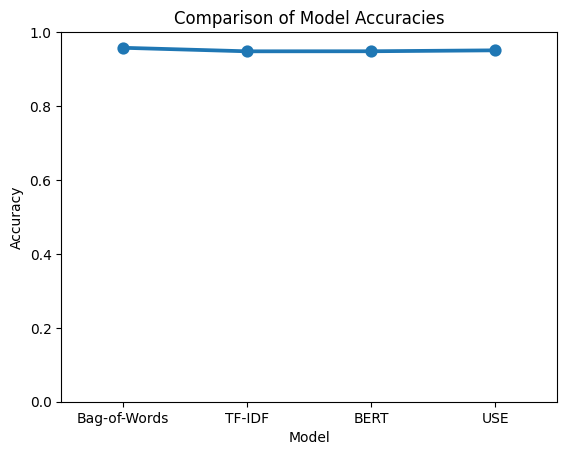

In [20]:
import matplotlib.pyplot as plt

sns.pointplot(x=model_names, y=accuracies)
plt.title('Comparison of Model Accuracies')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.show()